# Notebook 2 -- Cross-model vote comparison

Descriptive comparison of the three models' votes, built entirely on the
tables produced by notebook 1 (`llm_vote_game_level.csv` +
`llm_vote_file_level.csv` per model, and the shared human tables under
`analysis/human_outcomes/`).

**Reading guide.** Every stochastic quantity uses the empirical distribution
over the 3 T=1 runs (see notebook 1's rationale); the greedy run is always a
separate categorical view. Accuracy is always reported next to the
**random-vote baseline** for the same games, since roster sizes vary (3-6
players) and 64 of 191 games contain two Werewolves. Inference uses a single
tool throughout -- a **bootstrap over games**, paired whenever two models are
compared on the same games -- and a difference is quoted only when its CI
excludes 0. The human village votes serve as a *rough* difficulty /
social-signal proxy: humans hold private night information and their votes are
an outcome of the same dialogue the models read, so agreement with humans is
compatible with either conformity or shared evidence. The causal probes
(part 2) are the arbiter; this notebook only measures *where the votes land*.

Sections:

1. Corpus overview per model (accuracy vs chance, circle rates, instability)
2. Model-model agreement (probabilistic + greedy, circle included)
3. Models vs. the crowd: aligned / dissociated games, vote destinations,
   bootstrap CIs on the diagnostic shares
4. Who gets wrongly accused: roles, the Tanner trap
5. Start-role vs end-role Werewolf (night-swap sensitivity)
6. Success vs human solvability
7. Export: per-(model, game) table for the surrogate-model step


## Setup and loading

In [1]:
from pathlib import Path
from typing import Optional
from collections import Counter
from itertools import combinations
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_NAME = "masters_thesis_sdg"
MODEL_STAGE = "base"
PROMPT_DIR = "prompt_v4"
MIN_VILLAGE_VOTERS = 2
CIRCLE_VOTE_STRING = "No Werewolf"
N_BOOT = 5000
BOOT_SEED = 0


def bootstrap_mean_ci(values, n_boot=N_BOOT, alpha=0.05, seed=BOOT_SEED):
    """95% percentile bootstrap CI for a mean, resampling games.

    This is the *only* inference tool used in this notebook. The game is the
    sampling unit throughout. Where two models are compared they are scored on
    the same games, so the per-game difference is resampled (a paired
    bootstrap): game difficulty cancels and the CI is about the models, not
    about which games happened to fall in the corpus. A difference is quotable
    only when its CI excludes 0.

    Each call seeds its own generator, so a reported CI depends only on the
    values passed in -- never on how many bootstraps ran before it. Adding,
    removing or reordering an analysis therefore cannot shift the CIs of the
    others. (Two calls on samples of equal length share the same resampling
    index matrix; each CI is still valid on its own, but their bootstrap noise
    is correlated, so do not read small differences *between* CIs as
    independent evidence.)
    """
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]
    if len(values) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(values), size=(n_boot, len(values)))
    boot = values[idx].mean(axis=1)
    lo, hi = np.percentile(boot, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(values.mean()), float(lo), float(hi)


def find_repo_root(start: Optional[Path] = None, repo_name: str = REPO_NAME) -> Path:
    current = (start or Path.cwd()).resolve()
    while True:
        if current.name == repo_name:
            return current
        if current.parent == current:
            raise FileNotFoundError(f"Could not find repo root {repo_name!r}")
        current = current.parent


def parse_json(value, default):
    if isinstance(value, (list, dict)):
        return value
    if not isinstance(value, str) or not value.strip():
        return default
    try:
        return json.loads(value)
    except json.JSONDecodeError:
        return default


def short_model_label(folder_name: str) -> str:
    m = re.search(r"(\d+B)", folder_name)
    return m.group(1) if m else folder_name


REPO_ROOT = find_repo_root()
ANALYSIS_ROOT = REPO_ROOT / "analysis"
TABLES_REL = Path(MODEL_STAGE) / "voting" / PROMPT_DIR / "vote_stability" / "tables"
HUMAN_TABLES_DIR = ANALYSIS_ROOT / "human_outcomes" / "vote_tables"
OUTPUT_DIR = ANALYSIS_ROOT / "cross_model" / MODEL_STAGE / "voting" / PROMPT_DIR / "tables"
print("REPO_ROOT:", REPO_ROOT)


REPO_ROOT: C:\Users\annab\Documents\GitHub\masters_thesis_sdg


In [2]:
# Discover per-model tables produced by notebook 1.
game_frames, file_frames = [], []
for model_dir in sorted(ANALYSIS_ROOT.iterdir()):
    tables = model_dir / TABLES_REL
    if not (tables / "llm_vote_game_level.csv").exists():
        continue
    label = short_model_label(model_dir.name)
    g = pd.read_csv(tables / "llm_vote_game_level.csv")
    g["model"] = label
    for col, default in [("player_names", []), ("start_roles", []), ("end_roles", []),
                         ("correct_player_names", []), ("stoch_vote_distribution", {})]:
        g[col] = g[col].apply(lambda v: parse_json(v, default))
    game_frames.append(g)
    f = pd.read_csv(tables / "llm_vote_file_level.csv")
    f["model"] = label
    file_frames.append(f)

games = pd.concat(game_frames, ignore_index=True)
votes = pd.concat(file_frames, ignore_index=True)
MODELS = sorted(games["model"].unique())
print(f"Models: {MODELS}")
print(f"game-level rows: {len(games)} | file-level rows: {len(votes)}")

# Human tables (shared, model-agnostic).
village = pd.read_csv(HUMAN_TABLES_DIR / "village_vote_dispersion.csv")
village["village_vote_counts"] = village["village_vote_counts"].apply(lambda v: parse_json(v, {}))
village["village_top_target_names"] = village["village_top_target_names"].apply(lambda v: set(parse_json(v, [])))
village = village[village["n_village_aligned_votes"] >= MIN_VILLAGE_VOTERS].copy()
human_outcomes = pd.read_csv(HUMAN_TABLES_DIR / "human_game_outcomes.csv")
print(f"human village games kept (>= {MIN_VILLAGE_VOTERS} voters): {len(village)}")


Models: ['2B', '31B', '4B']
game-level rows: 573 | file-level rows: 2292
human village games kept (>= 2 voters): 169


In [3]:
# Merge game-level model rows with human info; classify games.
def classify_game(modal_targets: set, wolves: set) -> str:
    # aligned: every modal target is a Werewolf; dissociated: none is;
    # mixed_tie: a tie containing both. Diagnostic analyses use dissociated only.
    if not wolves:
        return "no_werewolf"
    if not modal_targets:
        return "no_human_votes"
    hits = modal_targets & wolves
    if hits == modal_targets:
        return "aligned"
    if not hits:
        return "dissociated"
    return "mixed_tie"


games["wolves"] = games["correct_player_names"].apply(set)
merged = games.merge(
    village[["game_id", "n_village_aligned_votes", "village_vote_counts",
             "village_top_target_names", "village_top_share",
             "village_vote_entropy", "village_modal_correct"]],
    on="game_id", how="inner",
)
merged["game_class"] = [
    classify_game(r["village_top_target_names"], r["wolves"]) for _, r in merged.iterrows()
]

one_model = merged[merged["model"] == MODELS[0]]
print("Game classification (games with human data, per game):")
display(one_model["game_class"].value_counts().rename_axis("game_class").to_frame("n_games"))
print(f"(model, game) rows: {len(merged)}; per model: {merged.groupby('model').size().to_dict()}")


Game classification (games with human data, per game):


,n_games
game_class,
aligned,71
dissociated,47
mixed_tie,28
no_werewolf,23


(model, game) rows: 507; per model: {'2B': 169, '31B': 169, '4B': 169}


## 1. Corpus overview per model

Accuracy proxies (mean `p_correct`, greedy accuracy), circle-vote behavior, and
within-model instability, over all evaluable games. Circle voting is a real
epistemic stance ("I see no werewolf"), not noise, so it is reported, not
dropped.

Every accuracy figure is reported against the **random-vote baseline**: a voter
picking uniformly among the roster plus the "No Werewolf" option, correct with
probability `n_werewolves / (n_players + 1)` when a Werewolf exists and
`1 / (n_players + 1)` when none does. It is computed per game and then
averaged, so it carries exactly the same game mix (roster sizes, number of
Werewolves, no-Werewolf games) as the model scores it is compared with. An
accuracy quoted without it is uninterpretable here: rosters have 3-6 players
and 64 of 191 games contain two Werewolves.


In [4]:
def stoch_circle_mass(dist: dict) -> float:
    return float(dist.get(CIRCLE_VOTE_STRING, 0.0))


def chance_p_correct(row: pd.Series) -> float:
    """Accuracy of a uniform random vote over the roster plus 'No Werewolf'."""
    n_options = len(row["player_names"]) + 1
    n_ww = len(row["wolves"])
    return (n_ww / n_options) if n_ww else (1.0 / n_options)


games["chance_p_correct"] = games.apply(chance_p_correct, axis=1)

overview = (
    games.assign(circle_mass=games["stoch_vote_distribution"].apply(stoch_circle_mass),
                 greedy_is_circle=games["greedy_vote"] == CIRCLE_VOTE_STRING)
    .groupby("model")
    .agg(n_games=("game_id", "size"),
         mean_p_correct=("p_correct", "mean"),
         chance_baseline=("chance_p_correct", "mean"),
         greedy_accuracy=("greedy_correct", "mean"),
         mean_stoch_entropy=("stoch_entropy", "mean"),
         stoch_circle_mass=("circle_mass", "mean"),
         greedy_circle_rate=("greedy_is_circle", "mean"),
         strict_majority_rate=("has_strict_majority", "mean"))
    .round(3)
)
overview.insert(3, "lift_vs_chance",
                (overview["mean_p_correct"] / overview["chance_baseline"]).round(2))
display(overview)


,n_games,mean_p_correct,chance_baseline,lift_vs_chance,greedy_accuracy,mean_stoch_entropy,stoch_circle_mass,greedy_circle_rate,strict_majority_rate
model,,,,,,,,,
2B,191,0.407,0.246,1.65,0.366,0.385,0.229,0.251,0.895
31B,191,0.417,0.246,1.70,0.440,0.275,0.120,0.126,0.932
4B,191,0.412,0.246,1.67,0.408,0.338,0.059,0.094,0.911


### Is the accuracy above chance, and do the models differ from each other?

Two questions, one tool -- the bootstrap over games defined in the setup:

1. **Above chance?** Per game, `p_correct - chance_p_correct` is the model's
   edge over random voting on *that* game. Bootstrapping its mean gives a CI on
   the corpus-level edge, which excludes 0 iff the model beats chance.
2. **Do the models differ?** All three models vote on the same 191 games, so
   the per-game difference `p_correct(A) - p_correct(B)` is bootstrapped
   **paired**: game difficulty cancels and the CI isolates the model effect. A
   ranking is quotable only where the CI excludes 0.
3. **Does greedy decoding beat sampling?** Within a model, `greedy_correct` and
   `p_correct` are two estimates of the same model's accuracy under two
   decoding modes, on the same games, so their per-game difference is
   bootstrapped paired as well. Note `p_correct` is itself estimated from only
   3 draws, which adds noise to the difference and makes this comparison
   *conservative*: it will not manufacture a gap that is not there.


In [5]:
# 1. Each model against its own random-vote baseline (paired within game).
edge_rows = []
for m in MODELS:
    sub = games[games["model"] == m]
    edge, lo, hi = bootstrap_mean_ci((sub["p_correct"] - sub["chance_p_correct"]).values)
    edge_rows.append({"model": m, "n_games": len(sub),
                      "mean_p_correct": sub["p_correct"].mean(),
                      "chance": sub["chance_p_correct"].mean(),
                      "edge": edge, "ci_low": lo, "ci_high": hi,
                      "above_chance": bool(lo > 0)})
print("Accuracy vs the random-vote baseline (95% bootstrap CI on the per-game edge):")
display(pd.DataFrame(edge_rows).round(3))

# 2. Paired between-model differences, same games for both models.
acc_piv = games.pivot_table(index="game_id", columns="model", values="p_correct")
greedy_piv = (games.assign(gc=games["greedy_correct"].astype(float))
              .pivot_table(index="game_id", columns="model", values="gc"))
pair_rows = []
for metric, piv in [("p_correct", acc_piv), ("greedy_correct", greedy_piv)]:
    for a, b in combinations(MODELS, 2):
        paired = piv[[a, b]].dropna()
        diff, lo, hi = bootstrap_mean_ci((paired[a] - paired[b]).values)
        pair_rows.append({"metric": metric, "model_a": a, "model_b": b,
                          "n_paired_games": len(paired), "mean_diff": diff,
                          "ci_low": lo, "ci_high": hi,
                          "excludes_zero": bool(lo > 0 or hi < 0)})
print("Paired between-model accuracy differences (A - B), 95% bootstrap CI:")
display(pd.DataFrame(pair_rows).round(3))

# 3. Greedy vs stochastic decoding, within each model, paired within game.
decode_rows = []
for m in MODELS:
    sub = games[games["model"] == m]
    diff, lo, hi = bootstrap_mean_ci(
        (sub["greedy_correct"].astype(float) - sub["p_correct"]).values)
    decode_rows.append({"model": m, "n_games": len(sub),
                        "greedy_accuracy": sub["greedy_correct"].astype(float).mean(),
                        "mean_p_correct": sub["p_correct"].mean(),
                        "greedy_minus_stochastic": diff, "ci_low": lo, "ci_high": hi,
                        "excludes_zero": bool(lo > 0 or hi < 0)})
print("Greedy minus stochastic accuracy, within model (95% bootstrap CI):")
display(pd.DataFrame(decode_rows).round(3))


Accuracy vs the random-vote baseline (95% bootstrap CI on the per-game edge):


,model,n_games,mean_p_correct,chance,edge,ci_low,ci_high,above_chance
0,2B,191,0.407,0.246,0.161,0.104,0.220,True
1,31B,191,0.417,0.246,0.171,0.111,0.231,True
2,4B,191,0.412,0.246,0.166,0.108,0.223,True


Paired between-model accuracy differences (A - B), 95% bootstrap CI:


,metric,model_a,model_b,n_paired_games,mean_diff,ci_low,ci_high,excludes_zero
0,p_correct,2B,31B,191,-0.010,-0.084,0.061,False
1,p_correct,2B,4B,191,-0.005,-0.061,0.052,False
2,p_correct,31B,4B,191,0.005,-0.066,0.077,False
3,greedy_correct,2B,31B,191,-0.073,-0.162,0.016,False
4,greedy_correct,2B,4B,191,-0.042,-0.110,0.031,False
5,greedy_correct,31B,4B,191,0.031,-0.058,0.120,False


Greedy minus stochastic accuracy, within model (95% bootstrap CI):


,model,n_games,greedy_accuracy,mean_p_correct,greedy_minus_stochastic,ci_low,ci_high,excludes_zero
0,2B,191,0.366,0.407,-0.040,-0.087,0.005,False
1,31B,191,0.440,0.417,0.023,-0.028,0.073,False
2,4B,191,0.408,0.412,-0.003,-0.054,0.045,False


### Accuracy split by whether a Werewolf exists

Pooled accuracy hides an abstention effect: on the 26 games with no Werewolf,
`p_correct` **is** the model's circle-vote rate, so a model that rarely says
"No Werewolf" is scored as failing all of them regardless of how it read the
transcript. The two situations are therefore reported apart, each against its
own baseline.

In [6]:
split_acc = (games.groupby(["model", "has_werewolf"])
             .agg(n_games=("p_correct", "size"),
                  mean_p_correct=("p_correct", "mean"),
                  chance=("chance_p_correct", "mean")))
ci_rows = []
for (m, hw), sub in games.groupby(["model", "has_werewolf"]):
    _, lo, hi = bootstrap_mean_ci((sub["p_correct"] - sub["chance_p_correct"]).values)
    ci_rows.append({"model": m, "has_werewolf": hw, "edge_ci_low": lo, "edge_ci_high": hi})
split_acc = split_acc.join(pd.DataFrame(ci_rows).set_index(["model", "has_werewolf"]))
print("Accuracy by whether the game contains a Werewolf "
      "(CI is on the per-game edge over chance):")
display(split_acc.round(3))

Accuracy by whether the game contains a Werewolf (CI is on the per-game edge over chance):


n_games  mean_p_correct  chance  edge_ci_low  edge_ci_high
model has_werewolf                                                            
2B    False              26           0.474   0.193        0.142         0.425
      True              165           0.396   0.254        0.082         0.204
31B   False              26           0.385   0.193        0.028         0.378
      True              165           0.422   0.254        0.103         0.235
4B    False              26           0.154   0.193       -0.141         0.082
      True              165           0.453   0.254        0.136         0.263

## 2. Model-model agreement

**Mean pairwise vote agreement.** Every cell of the stochastic matrix answers
one question, and the same question: *take two separate generated votes, one
from the row model and one from the column model, on the same game -- how often
do they name the same target?* Circle votes ("No Werewolf") are ordinary vote
labels throughout, so a pair of circle votes counts as agreement.

Per game, with `V_{A,i}` the vote of run `i` of model A:

- **Off-diagonal (A != B)** -- all `3 x 3 = 9` cross-model run pairs, since the
  runs of A and B are independent and there is no meaningful correspondence
  between "run 1 of A" and "run 1 of B":
  `A_AB(g) = (1/9) * sum_i sum_j 1[V_{A,i}(g) = V_{B,j}(g)]`
- **Diagonal (A = B)** -- only the `C(3,2) = 3` *distinct* run pairs, excluding
  the self-pairs `i = j`:
  `A_AA(g) = (1/3) * (1[V_1=V_2] + 1[V_1=V_3] + 1[V_2=V_3])`

The per-game value is then averaged over games. The diagonal is therefore a
genuine **within-model stability** estimate: the probability that two separate
generations from the same model agree. It is the right reference point for the
off-diagonal cells -- between-model agreement should be read against how often
a model agrees with *itself*, not against 1.0.

*Why the self-pairs must go.* The earlier version used
`sum_x p_A(x)^2` on the diagonal. Expanded, that is
`(1/9) * sum_i sum_j 1[V_i = V_j]` over all 9 **ordered** pairs, which includes
the 3 self-pairs `i = j` that agree by definition. It is therefore bounded
below by 1/3 even when all three runs disagree, and it overstates stability. The
off-diagonal cells were never affected: `sum_x p_A(x) p_B(x)` expands exactly to
the 9-cross-pair mean above, so those values are unchanged by this revision.

**The greedy matrix is left as it was** and is only the categorical
counterpart: one deterministic vote per model per game, compared across models.
Its 100% diagonal is **tautological** -- greedy decoding is deterministic, so a
model trivially agrees with itself -- and must not be read as a stability
estimate. Only the stochastic diagonal measures stability.


In [7]:
def stoch_vote_label(row: pd.Series) -> str:
    """The vote a single run actually produced; circle is an ordinary label."""
    return CIRCLE_VOTE_STRING if bool(row["is_circle_vote"]) else row["chosen_player_name"]


# One list of generated vote labels per (model, game), one entry per stochastic
# run. Built from the run-level table rather than from the aggregated
# distribution, so the run pairs below are the actual generations.
stoch_votes = votes[(votes["decoding"] == "stochastic")
                    & votes["status"].isin(["player_vote", "circle_vote"])].copy()
stoch_votes["vote"] = stoch_votes.apply(stoch_vote_label, axis=1)
labels_by_model_game = stoch_votes.groupby(["model", "game_id"])["vote"].apply(list).to_dict()


def within_model_agreement(labels: list) -> float:
    """P(two DISTINCT runs of one model agree). Self-pairs i = j excluded."""
    pairs = list(combinations(range(len(labels)), 2))
    if not pairs:
        return np.nan
    return sum(labels[i] == labels[j] for i, j in pairs) / len(pairs)


def between_model_agreement(labels_a: list, labels_b: list) -> float:
    """P(one run of A and one run of B agree), over all n_A x n_B pairs."""
    if not labels_a or not labels_b:
        return np.nan
    return sum(a == b for a in labels_a for b in labels_b) / (len(labels_a) * len(labels_b))


greedy_by_model_game = {
    (r["model"], r["game_id"]): r["greedy_vote"]
    for _, r in games.iterrows() if pd.notna(r["greedy_vote"])
}
all_game_ids = games["game_id"].unique()

stoch_agree = pd.DataFrame(np.nan, index=MODELS, columns=MODELS)
greedy_agree = pd.DataFrame(np.nan, index=MODELS, columns=MODELS)
cell_n_games = pd.DataFrame(0, index=MODELS, columns=MODELS)

for m in MODELS:
    vals = [within_model_agreement(labels_by_model_game[(m, gid)])
            for gid in all_game_ids if (m, gid) in labels_by_model_game]
    vals = [v for v in vals if not np.isnan(v)]
    stoch_agree.loc[m, m] = np.mean(vals) if vals else np.nan
    cell_n_games.loc[m, m] = len(vals)
    greedy_agree.loc[m, m] = 1.0   # tautological: greedy is deterministic

for a, b in combinations(MODELS, 2):
    svals, gvals = [], []
    for gid in all_game_ids:
        la, lb = labels_by_model_game.get((a, gid)), labels_by_model_game.get((b, gid))
        if la and lb:
            svals.append(between_model_agreement(la, lb))
        ga, gb = greedy_by_model_game.get((a, gid)), greedy_by_model_game.get((b, gid))
        if ga is not None and gb is not None:
            gvals.append(ga == gb)
    stoch_agree.loc[a, b] = stoch_agree.loc[b, a] = np.mean(svals) if svals else np.nan
    cell_n_games.loc[a, b] = cell_n_games.loc[b, a] = len(svals)
    greedy_agree.loc[a, b] = greedy_agree.loc[b, a] = np.mean(gvals) if gvals else np.nan

assert np.allclose(stoch_agree.values, stoch_agree.values.T), "matrix is not symmetric"

runs_per_game = stoch_votes.groupby(["model", "game_id"]).size()
print(f"stochastic runs per (model, game): min={runs_per_game.min()}, "
      f"max={runs_per_game.max()}")
print("games contributing to each cell:")
print(cell_n_games.to_string())
print()
print("Mean pairwise vote agreement, % (every cell = P(two separate generated "
      "votes agree);")
print("diagonal = within-model, distinct run pairs only, self-pairs excluded):")
print((stoch_agree * 100).round(1).to_string())
print()
print("Within-model agreement (stability), quotable values:")
for m in MODELS:
    print(f"  {m:>4}: {stoch_agree.loc[m, m] * 100:.1f}%  (n={cell_n_games.loc[m, m]} games)")
print()
print("Between-model agreement:")
for a, b in combinations(MODELS, 2):
    print(f"  {a:>4} vs {b:<4}: {stoch_agree.loc[a, b] * 100:.1f}%  "
          f"(n={cell_n_games.loc[a, b]} games)")
print()
print("Greedy vote agreement, % (UNCHANGED; the 100% diagonal is tautological "
      "-- greedy is")
print("deterministic, so it is not a stability estimate):")
print((greedy_agree * 100).round(1).to_string())

stochastic runs per (model, game): min=3, max=3
games contributing to each cell:
      2B  31B   4B
2B   191  191  191
31B  191  191  191
4B   191  191  191

Mean pairwise vote agreement, % (every cell = P(two separate generated votes agree);
diagonal = within-model, distinct run pairs only, self-pairs excluded):
       2B   31B    4B
2B   61.3  43.0  51.0
31B  43.0  72.3  41.9
4B   51.0  41.9  66.0

Within-model agreement (stability), quotable values:
    2B: 61.3%  (n=191 games)
   31B: 72.3%  (n=191 games)
    4B: 66.0%  (n=191 games)

Between-model agreement:
    2B vs 31B : 43.0%  (n=191 games)
    2B vs 4B  : 51.0%  (n=191 games)
   31B vs 4B  : 41.9%  (n=191 games)

Greedy vote agreement, % (UNCHANGED; the 100% diagonal is tautological -- greedy is
deterministic, so it is not a stability estimate):
        2B    31B     4B
2B   100.0   41.4   53.9
31B   41.4  100.0   46.1
4B    53.9   46.1  100.0


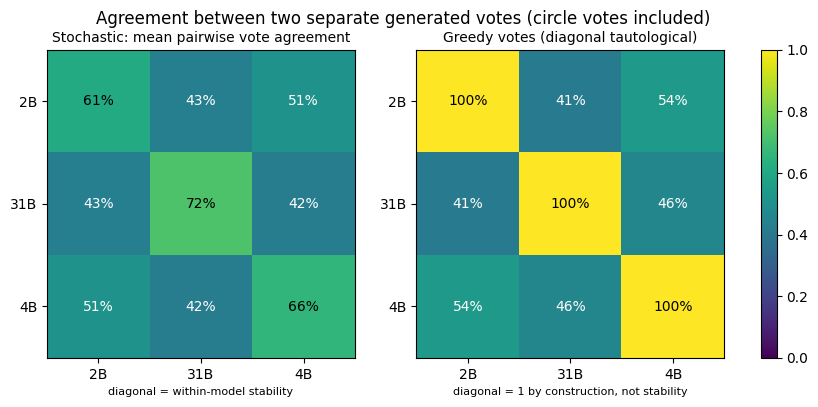

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, mat, title in [
    (axes[0], stoch_agree, "Stochastic: mean pairwise vote agreement"),
    (axes[1], greedy_agree, "Greedy votes (diagonal tautological)"),
]:
    im = ax.imshow(mat.values.astype(float), vmin=0, vmax=1, cmap="viridis")
    ax.set_xticks(range(len(MODELS))); ax.set_xticklabels(MODELS)
    ax.set_yticks(range(len(MODELS))); ax.set_yticklabels(MODELS)
    for i in range(len(MODELS)):
        for j in range(len(MODELS)):
            v = mat.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.0%}", ha="center", va="center",
                        color="white" if v < 0.6 else "black")
    ax.set_title(title, fontsize=10)
fig.suptitle("Agreement between two separate generated votes "
             "(circle votes included)")
axes[0].set_xlabel("diagonal = within-model stability", fontsize=8)
axes[1].set_xlabel("diagonal = 1 by construction, not stability", fontsize=8)
fig.colorbar(im, ax=axes, fraction=0.03)
plt.show()


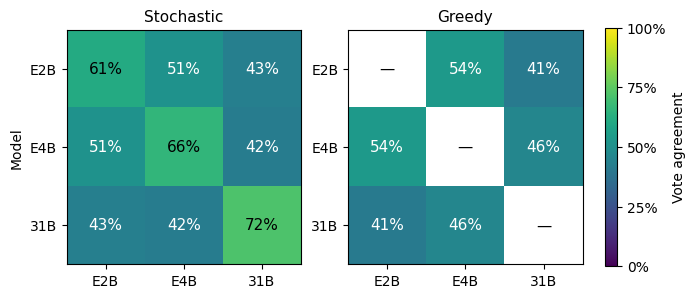

In [9]:
from matplotlib.ticker import PercentFormatter
# Thesis figure — stochastic and greedy cross-model vote agreement

# Keys used in the dataframes
order = ["2B", "4B", "31B"]

# Labels shown in the figure
display_labels = ["E2B", "E4B", "31B"]

stoch_mat = stoch_agree.loc[order, order].copy()
greedy_mat = greedy_agree.loc[order, order].copy()

# Greedy self-agreement is tautological, so do not display it
for i in range(len(order)):
    greedy_mat.iloc[i, i] = np.nan

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.1))

for ax, mat, title in [
    (axes[0], stoch_mat, "Stochastic"),
    (axes[1], greedy_mat, "Greedy"),
]:
    values = mat.values.astype(float)

    im = ax.imshow(
        values,
        vmin=0,
        vmax=1,
        cmap="viridis"
    )

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(display_labels)
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(display_labels)

    ax.set_title(title, fontsize=11)

    for i in range(len(order)):
        for j in range(len(order)):
            v = values[i, j]

            if np.isnan(v):
                ax.text(
                    j, i, "—",
                    ha="center",
                    va="center",
                    fontsize=11
                )
            else:
                ax.text(
                    j, i, f"{v:.0%}",
                    ha="center",
                    va="center",
                    fontsize=11,
                    color="white" if v < 0.6 else "black"
                )

axes[0].set_ylabel("Model")
axes[1].set_ylabel("")

cbar = fig.colorbar(
    im,
    ax=axes,
    fraction=0.035,
    pad=0.04,
    ticks=[0, 0.25, 0.50, 0.75, 1.00]
)

cbar.ax.yaxis.set_major_formatter(PercentFormatter(1.0))
cbar.set_label("Vote agreement")


fig.savefig(
    "model_vote_agreement.pdf",
    bbox_inches="tight"
)

fig.savefig(
    "model_vote_agreement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Models vs. the crowd

The human-referenced partition: **aligned** games (human modal target is a
Werewolf; non-diagnostic -- crowd-following and correct deduction predict the
same vote) vs. **dissociated** games (the crowd's modal pick is wrong; the only
games where the two hypotheses separate). Per model and class, the stochastic
vote mass is decomposed by destination, with precedence
werewolf > human_modal > other_human_target > unvoted (circle mass reported as
its own row since it names nobody).


,game_class,model,n_games,werewolf,human_modal,other_human_target,unvoted_player,circle
0,aligned,2B,71,0.531,0.000,0.056,0.263,0.150
1,aligned,31B,71,0.615,0.000,0.066,0.268,0.052
2,aligned,4B,71,0.592,0.000,0.038,0.352,0.019
3,dissociated,2B,47,0.248,0.411,0.021,0.149,0.170
4,dissociated,31B,47,0.184,0.475,0.007,0.248,0.085
5,dissociated,4B,47,0.255,0.411,0.028,0.284,0.021


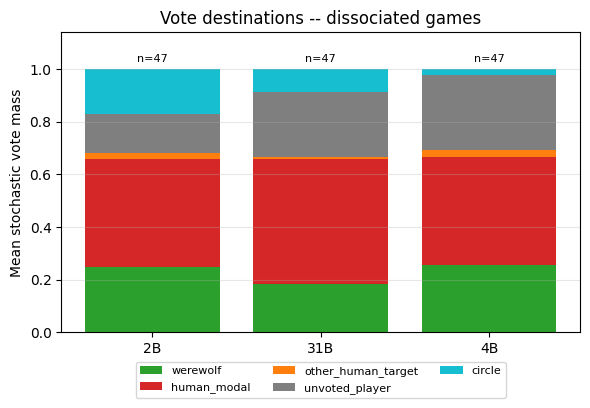

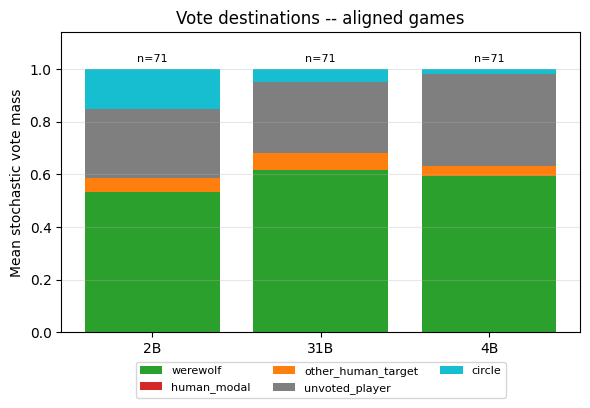

In [10]:
DEST_CATEGORIES = ["werewolf", "human_modal", "other_human_target", "unvoted_player", "circle"]
DEST_COLORS = {"werewolf": "#2ca02c", "human_modal": "#d62728",
               "other_human_target": "#ff7f0e", "unvoted_player": "#7f7f7f", "circle": "#17becf"}


def destination_shares(row: pd.Series) -> Optional[dict]:
    dist = row["stoch_vote_distribution"]
    if not dist:
        return None
    shares = dict.fromkeys(DEST_CATEGORIES, 0.0)
    for label, mass in dist.items():
        if label == CIRCLE_VOTE_STRING:
            shares["circle"] += mass
        elif label in row["wolves"]:
            shares["werewolf"] += mass
        elif label in row["village_top_target_names"]:
            shares["human_modal"] += mass
        elif label in row["village_vote_counts"]:
            shares["other_human_target"] += mass
        else:
            shares["unvoted_player"] += mass
    return shares


share_rows = []
for _, r in merged.iterrows():
    s = destination_shares(r)
    if s is None:
        continue
    share_rows.append({"model": r["model"], "game_id": r["game_id"], "game_class": r["game_class"], **s})
shares_df = pd.DataFrame(share_rows)

dest_summary = (
    shares_df[shares_df["game_class"].isin(["dissociated", "aligned"])]
    .groupby(["game_class", "model"])
    .agg(n_games=("werewolf", "size"), **{c: (c, "mean") for c in DEST_CATEGORIES})
    .round(3).reset_index()
)
display(dest_summary)

for game_class in ["dissociated", "aligned"]:
    sub = dest_summary[dest_summary["game_class"] == game_class].set_index("model").reindex(MODELS).dropna(how="all")
    if sub.empty:
        continue
    fig, ax = plt.subplots(figsize=(6, 4.2))
    x = np.arange(len(sub)); bottom = np.zeros(len(sub))
    for cat in DEST_CATEGORIES:
        vals = sub[cat].values.astype(float)
        ax.bar(x, vals, bottom=bottom, label=cat, color=DEST_COLORS[cat])
        bottom += vals
    for i, (_, r) in enumerate(sub.iterrows()):
        ax.text(i, 1.02, f"n={int(r['n_games'])}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels(sub.index); ax.set_ylim(0, 1.14)
    ax.set_ylabel("Mean stochastic vote mass")
    ax.set_title(f"Vote destinations -- {game_class} games")
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout(); plt.show()


### Bootstrap CIs on the diagnostic shares

Per-model 95% percentile CIs (resampling games) on the werewolf and
human-modal shares in dissociated games, and **paired** between-model
differences (resampling only games both models share, which holds game
difficulty fixed). A ranking is quotable only where the paired CI excludes 0.


In [11]:
diss = shares_df[shares_df["game_class"] == "dissociated"]
ci_rows = []
for m in MODELS:
    sub = diss[diss["model"] == m]
    for cat in ["werewolf", "human_modal"]:
        mean, lo, hi = bootstrap_mean_ci(sub[cat].values)
        ci_rows.append({"model": m, "category": cat, "n_games": len(sub),
                        "mean": mean, "ci_low": lo, "ci_high": hi})
display(pd.DataFrame(ci_rows).round(3))

pair_rows = []
for cat in ["werewolf", "human_modal"]:
    piv = diss.pivot_table(index="game_id", columns="model", values=cat)
    for a, b in combinations(MODELS, 2):
        if a not in piv.columns or b not in piv.columns:
            continue
        paired = piv[[a, b]].dropna()
        if paired.empty:
            continue
        mean, lo, hi = bootstrap_mean_ci((paired[a] - paired[b]).values)
        pair_rows.append({"model_a": a, "model_b": b, "category": cat,
                          "n_paired_games": len(paired), "mean_diff": mean,
                          "ci_low": lo, "ci_high": hi,
                          "excludes_zero": bool(lo > 0 or hi < 0)})
print("Paired between-model differences (A - B), 95% bootstrap CI:")
display(pd.DataFrame(pair_rows).round(3))


,model,category,n_games,mean,ci_low,ci_high
0,2B,werewolf,47,0.248,0.149,0.355
1,2B,human_modal,47,0.411,0.298,0.532
2,31B,werewolf,47,0.184,0.099,0.277
3,31B,human_modal,47,0.475,0.348,0.603
4,4B,werewolf,47,0.255,0.149,0.369
5,4B,human_modal,47,0.411,0.291,0.539


Paired between-model differences (A - B), 95% bootstrap CI:


,model_a,model_b,category,n_paired_games,mean_diff,ci_low,ci_high,excludes_zero
0,2B,31B,werewolf,47,0.064,-0.050,0.177,False
1,2B,4B,werewolf,47,-0.007,-0.099,0.092,False
2,31B,4B,werewolf,47,-0.071,-0.184,0.050,False
3,2B,31B,human_modal,47,-0.064,-0.177,0.057,False
4,2B,4B,human_modal,47,-0.000,-0.092,0.085,False
5,31B,4B,human_modal,47,0.064,-0.064,0.199,False


## 4. Who gets wrongly accused: roles and the Tanner trap

Among stochastic vote mass on named, non-Werewolf targets, the distribution
over the target's **end role** (mass-weighted, so a 2/3 vote counts as 2/3).
Voting the Tanner is a specific self-inflicted loss, so it is called out, and
the follow-up asks: on games where the *crowd's* modal target is a Tanner, do
the models walk onto the same trap?


Share of wrong (named, non-Werewolf) stochastic vote mass, by end role of the accused:


role,Robber,Tanner,Troublemaker,Villager,Seer,Insomniac,Minion,Hunter,Mason,Drunk,Center Card,Doppelganger
model,,,,,,,,,,,,
2B,24.4,22.8,12.2,13.4,8.9,9.8,4.1,3.7,0.4,0.4,0.0,0.0
31B,25.4,21.4,14.9,13.6,10.2,3.4,4.4,2.7,1.0,1.4,0.7,1.0
4B,23.2,16.8,14.3,14.3,15.2,6.0,3.5,4.8,1.0,0.3,0.6,0.0


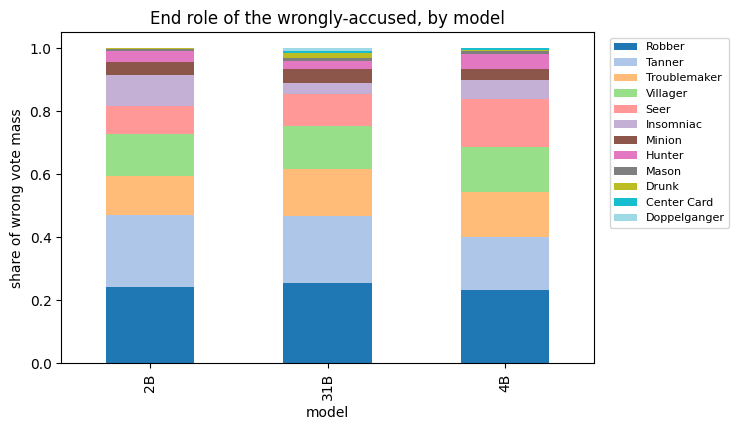

In [12]:
def role_of(label: str, row: pd.Series) -> Optional[str]:
    names = row["player_names"]
    if label in names:
        return row["end_roles"][names.index(label)]
    return None


wrong_role_rows = []
for _, r in games.iterrows():
    for label, mass in r["stoch_vote_distribution"].items():
        if label == CIRCLE_VOTE_STRING or label in r["wolves"]:
            continue
        role = role_of(label, r)
        if role is not None:
            wrong_role_rows.append({"model": r["model"], "role": role, "mass": mass})
wrong_roles = pd.DataFrame(wrong_role_rows)
role_share = wrong_roles.groupby(["model", "role"])["mass"].sum().rename("mass").reset_index()
role_share["share"] = role_share["mass"] / role_share.groupby("model")["mass"].transform("sum")
pivot = role_share.pivot_table(index="model", columns="role", values="share", fill_value=0).reindex(MODELS)
pivot = pivot[pivot.sum().sort_values(ascending=False).index]
print("Share of wrong (named, non-Werewolf) stochastic vote mass, by end role of the accused:")
display((pivot * 100).round(1))

pivot.plot(kind="bar", stacked=True, figsize=(7.5, 4.4), colormap="tab20")
plt.ylabel("share of wrong vote mass"); plt.title("End role of the wrongly-accused, by model")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()


### Normalizing by role availability

Raw shares are confounded by base rates: not every role appears in every game,
and frequent roles (Robber, Villager) collect wrong votes partly because they
are simply *there*. For each model and role, the observed share of wrong vote
mass is compared with the role's **opportunity share** -- the fraction of
non-Werewolf seats that role occupies, weighted per game by how much wrong
mass the model actually spent there. Their ratio is a **lift**: 1 = accused
exactly as often as random accusation among non-Werewolves would predict,
2 = accused twice as often per seat available. Roles with tiny opportunity
shares get noisy lifts, so opportunity is reported alongside.


In [13]:
lift_rows = []
for _, r in games.iterrows():
    dist = r["stoch_vote_distribution"]
    names, ends = r["player_names"], r["end_roles"]
    nonwolf_seats = [role for role in ends if role != "Werewolf"]
    if not dist or not nonwolf_seats:
        continue
    wrong_mass = sum(v for k, v in dist.items()
                     if k != CIRCLE_VOTE_STRING and k not in r["wolves"] and k in names)
    if wrong_mass == 0:
        continue
    seat_counts = Counter(nonwolf_seats)
    for role, n_seats in seat_counts.items():
        observed = sum(v for k, v in dist.items()
                       if k in names and ends[names.index(k)] == role and k not in r["wolves"])
        expected = wrong_mass * n_seats / len(nonwolf_seats)
        lift_rows.append({"model": r["model"], "role": role,
                          "observed_mass": observed, "expected_mass": expected})

lift_df = (pd.DataFrame(lift_rows).groupby(["model", "role"])[["observed_mass", "expected_mass"]]
           .sum().reset_index())
totals = lift_df.groupby("model")["observed_mass"].transform("sum")
lift_df["observed_share"] = lift_df["observed_mass"] / totals
lift_df["opportunity_share"] = lift_df["expected_mass"] / lift_df.groupby("model")["expected_mass"].transform("sum")
lift_df["lift"] = lift_df["observed_mass"] / lift_df["expected_mass"]

lift_pivot = lift_df.pivot_table(index="role", columns="model", values="lift").reindex(
    lift_df.groupby("role")["expected_mass"].sum().sort_values(ascending=False).index)
opp = lift_df.groupby("role")["opportunity_share"].mean().reindex(lift_pivot.index)
table = lift_pivot.round(2)
table["mean_opportunity_share"] = (opp * 100).round(1)
print("Accusation lift by end role (1 = proportional to seat availability):")
display(table)


Accusation lift by end role (1 = proportional to seat availability):


model,2B,31B,4B,mean_opportunity_share
role,,,,
Robber,1.20,1.22,1.21,20.1
Troublemaker,0.64,0.80,0.71,19.3
Seer,0.57,0.67,0.91,15.9
Tanner,1.49,1.46,1.19,14.7
Villager,1.34,1.31,1.27,10.5
Insomniac,1.25,0.44,0.87,7.5
Minion,0.78,0.91,0.73,4.9
Hunter,1.07,1.22,1.82,2.8
Mason,0.56,0.50,0.87,1.3


### Bootstrap CIs on the lift

95% percentile CIs, resampling **games** with replacement (the game is the
sampling unit, 191 games, 5,000 replicates). Two properties matter for the
interpretation:

- **Games are resampled jointly across models.** A replicate draws one set of
  191 game indices and applies it to all three models, so the three lifts in a
  replicate are computed on the same games. Between-model comparisons therefore
  are not contaminated by which games happened to be drawn.
- **The lift is recomputed inside each replicate**, as
  `sum(observed mass) / sum(expected mass)` over the resampled games -- a ratio
  of sums, not an average of per-game ratios. Nothing is resampled from the
  aggregated role-level rows.

The per-game observed and expected masses are exactly those built above, so the
bootstrap point estimate reproduces `lift_df["lift"]` identically (asserted
below). This bootstrap draws from its own generator with its own seed, so it is
unaffected by, and does not affect, any other bootstrap in the notebook.


In [14]:
LIFT_N_BOOT = 5000
LIFT_BOOT_SEED = 20260822        # independent of BOOT_SEED used elsewhere
MIN_OPPORTUNITY_SHARE = 0.04     # roles kept in the thesis figure
LIFT_MODEL_ORDER = ["2B", "4B", "31B"]
LIFT_MODEL_LABELS = {"2B": "E2B", "4B": "E4B", "31B": "31B"}

# Per-game contribution of every (model, role) cell, over all 191 games.
# Games contributing no wrong mass enter as exact zeros rather than being
# dropped, so the sampling population is the full set of 191 games.
game_ids = sorted(games["game_id"].unique())
game_pos = {g: i for i, g in enumerate(game_ids)}
cells_index = sorted({(r["model"], r["role"]) for _, r in lift_df.iterrows()})
cell_pos = {c: i for i, c in enumerate(cells_index)}

obs_mat = np.zeros((len(cells_index), len(game_ids)))
exp_mat = np.zeros((len(cells_index), len(game_ids)))
for _, r in games.iterrows():
    dist = r["stoch_vote_distribution"]
    names, ends = r["player_names"], r["end_roles"]
    nonwolf_seats = [role for role in ends if role != "Werewolf"]
    if not dist or not nonwolf_seats:
        continue
    wrong_mass = sum(v for k, v in dist.items()
                     if k != CIRCLE_VOTE_STRING and k not in r["wolves"] and k in names)
    if wrong_mass == 0:
        continue
    gi = game_pos[r["game_id"]]
    for role, n_seats in Counter(nonwolf_seats).items():
        ci = cell_pos.get((r["model"], role))
        if ci is None:
            continue
        obs_mat[ci, gi] += sum(v for k, v in dist.items()
                               if k in names and ends[names.index(k)] == role
                               and k not in r["wolves"])
        exp_mat[ci, gi] += wrong_mass * n_seats / len(nonwolf_seats)

# Point estimate through the bootstrap machinery must equal the existing one.
point = obs_mat.sum(axis=1) / exp_mat.sum(axis=1)
lift_check = lift_df.set_index(["model", "role"]).loc[cells_index, "lift"].values
assert np.allclose(point, lift_check, equal_nan=True), "bootstrap path changed the point estimate"
print(f"point-estimate check: bootstrap path reproduces lift_df exactly for all "
      f"{len(cells_index)} (model, role) cells -> "
      f"max abs diff {np.nanmax(np.abs(point - lift_check)):.2e}")

# One shared set of resampled game indices per replicate, applied to all models.
lift_rng = np.random.default_rng(LIFT_BOOT_SEED)
draws = lift_rng.integers(0, len(game_ids), size=(LIFT_N_BOOT, len(game_ids)))
counts = np.stack([np.bincount(row, minlength=len(game_ids)) for row in draws]).astype(float)

boot_obs = counts @ obs_mat.T          # (n_boot, n_cells)
boot_exp = counts @ exp_mat.T
with np.errstate(divide="ignore", invalid="ignore"):
    boot_lift = np.where(boot_exp > 0, boot_obs / boot_exp, np.nan)

n_undefined = int(np.isnan(boot_lift).sum())
if n_undefined:
    print(f"note: {n_undefined} of {boot_lift.size} replicate-cells had zero expected "
          "mass (role absent from the resample) and are excluded from their percentiles")

ci_low = np.nanpercentile(boot_lift, 2.5, axis=0)
ci_high = np.nanpercentile(boot_lift, 97.5, axis=0)

lift_ci = pd.DataFrame({
    "model": [c[0] for c in cells_index],
    "role": [c[1] for c in cells_index],
    "lift": point, "ci_low": ci_low, "ci_high": ci_high,
})
opp_by_role = lift_df.groupby("role")["opportunity_share"].mean()
lift_ci["mean_opportunity_share"] = lift_ci["role"].map(opp_by_role)

figure_roles = [r for r in lift_pivot.index
                if opp_by_role.get(r, 0.0) >= MIN_OPPORTUNITY_SHARE]
lift_ci["in_figure"] = lift_ci["role"].isin(figure_roles)

out = lift_ci.copy()
out["mean_opportunity_share"] = (out["mean_opportunity_share"] * 100).round(1)
out["model"] = pd.Categorical(out["model"], LIFT_MODEL_ORDER, ordered=True)
out["role"] = pd.Categorical(out["role"], list(lift_pivot.index), ordered=True)
out = out.sort_values(["role", "model"])
print()
print("Accusation lift with 95% percentile bootstrap CIs "
      f"({LIFT_N_BOOT} replicates, games resampled jointly across models):")
display(out[["role", "model", "lift", "ci_low", "ci_high",
             "mean_opportunity_share", "in_figure"]].round(3).reset_index(drop=True))

fig_ci = lift_ci[lift_ci["in_figure"]]
above = fig_ci[fig_ci["ci_low"] > 1.0]
below = fig_ci[fig_ci["ci_high"] < 1.0]
crossing = fig_ci[(fig_ci["ci_low"] <= 1.0) & (fig_ci["ci_high"] >= 1.0)]


def fmt(df):
    if df.empty:
        return "    (none)"
    rows = df.sort_values(["role", "model"])
    return "\n".join(f"    {r['role']:<13} {LIFT_MODEL_LABELS[r['model']]:>4}: "
                      f"lift {r['lift']:.2f}  CI [{r['ci_low']:.2f}, {r['ci_high']:.2f}]"
                      for _, r in rows.iterrows())


print(f"\nSummary over the {len(figure_roles)} figure roles "
      f"(mean opportunity share >= {MIN_OPPORTUNITY_SHARE:.0%}), "
      f"{len(fig_ci)} model-role cells:")
print(f"\n  CI entirely ABOVE 1 (over-accused), n={len(above)}:")
print(fmt(above))
print(f"\n  CI entirely BELOW 1 (under-accused), n={len(below)}:")
print(fmt(below))
print(f"\n  CI CROSSES 1 (not distinguishable from proportional), n={len(crossing)}:")
print(fmt(crossing))

point-estimate check: bootstrap path reproduces lift_df exactly for all 42 (model, role) cells -> max abs diff 2.22e-16
note: 12117 of 210000 replicate-cells had zero expected mass (role absent from the resample) and are excluded from their percentiles



Accusation lift with 95% percentile bootstrap CIs (5000 replicates, games resampled jointly across models):


,role,model,lift,ci_low,ci_high,mean_opportunity_share,in_figure
0,Robber,2B,1.200,0.868,1.550,20.1,True
1,Robber,4B,1.215,0.890,1.555,20.1,True
2,Robber,31B,1.218,0.884,1.566,20.1,True
3,Troublemaker,2B,0.638,0.355,0.941,19.3,True
4,Troublemaker,4B,0.708,0.461,0.977,19.3,True
5,Troublemaker,31B,0.796,0.495,1.130,19.3,True
6,Seer,2B,0.565,0.313,0.873,15.9,True
7,Seer,4B,0.915,0.609,1.247,15.9,True
8,Seer,31B,0.675,0.383,0.995,15.9,True
9,Tanner,2B,1.491,1.067,1.897,14.7,True



Summary over the 7 figure roles (mean opportunity share >= 4%), 21 model-role cells:

  CI entirely ABOVE 1 (over-accused), n=2:
    Tanner         E2B: lift 1.49  CI [1.07, 1.90]
    Tanner         31B: lift 1.46  CI [1.07, 1.85]

  CI entirely BELOW 1 (under-accused), n=5:
    Insomniac      31B: lift 0.44  CI [0.16, 0.79]
    Seer           E2B: lift 0.57  CI [0.31, 0.87]
    Seer           31B: lift 0.67  CI [0.38, 1.00]
    Troublemaker   E2B: lift 0.64  CI [0.36, 0.94]
    Troublemaker   E4B: lift 0.71  CI [0.46, 0.98]

  CI CROSSES 1 (not distinguishable from proportional), n=14:
    Insomniac      E2B: lift 1.25  CI [0.63, 1.95]
    Insomniac      E4B: lift 0.87  CI [0.43, 1.34]
    Minion         E2B: lift 0.78  CI [0.21, 1.45]
    Minion         31B: lift 0.91  CI [0.31, 1.55]
    Minion         E4B: lift 0.73  CI [0.20, 1.36]
    Robber         E2B: lift 1.20  CI [0.87, 1.55]
    Robber         31B: lift 1.22  CI [0.88, 1.57]
    Robber         E4B: lift 1.21  CI [0.89, 1.5

bar-height check: all 21 bars match the computed lifts (max abs diff 0.0051)
note: these cells were double-rounded in the quoted list; the bar uses the exact value:
    Robber         E4B: exact 1.2150 -> 2dp 1.21  (quoted 1.22)
    Seer           E4B: exact 0.9149 -> 2dp 0.91  (quoted 0.92)
    Seer           31B: exact 0.6749 -> 2dp 0.67  (quoted 0.68)


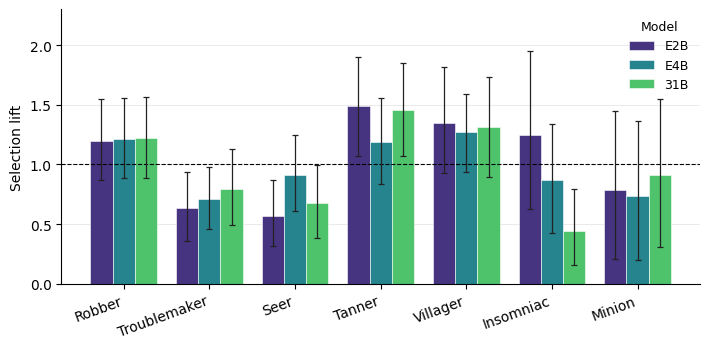


Final plotting table (row order = plotting order):


,role,model,lift,ci_low,ci_high,mean_opportunity_share_pct
0,Robber,E2B,1.200,0.868,1.550,20.1
1,Robber,E4B,1.215,0.890,1.555,20.1
2,Robber,31B,1.218,0.884,1.566,20.1
3,Troublemaker,E2B,0.638,0.355,0.941,19.3
4,Troublemaker,E4B,0.708,0.461,0.977,19.3
5,Troublemaker,31B,0.796,0.495,1.130,19.3
6,Seer,E2B,0.565,0.313,0.873,15.9
7,Seer,E4B,0.915,0.609,1.247,15.9
8,Seer,31B,0.675,0.383,0.995,15.9
9,Tanner,E2B,1.491,1.067,1.897,14.7


In [15]:
# Thesis figure -- normalized wrong-vote role lift.
# Uses the point estimates and bootstrap CIs already computed above
# (lift_ci); nothing is recomputed here.

FIG_ROLE_ORDER = list(figure_roles)          # opportunity-share order, not lift order
FIG_COLORS = plt.cm.viridis([0.15, 0.45, 0.72])

lookup = lift_ci.set_index(["model", "role"])

# --- verification against the quoted point estimates, before plotting --------
QUOTED = {
    "Robber":       (1.20, 1.22, 1.22),
    "Troublemaker": (0.64, 0.71, 0.80),
    "Seer":         (0.57, 0.92, 0.68),
    "Tanner":       (1.49, 1.19, 1.46),
    "Villager":     (1.34, 1.27, 1.31),
    "Insomniac":    (1.25, 0.87, 0.44),
    "Minion":       (0.78, 0.73, 0.91),
}
assert FIG_ROLE_ORDER == list(QUOTED), f"role order changed: {FIG_ROLE_ORDER}"

check_rows = []
for role in FIG_ROLE_ORDER:
    for m, quoted in zip(LIFT_MODEL_ORDER, QUOTED[role]):
        actual = float(lookup.loc[(m, role), "lift"])
        check_rows.append({"role": role, "model": LIFT_MODEL_LABELS[m],
                           "bar_height": actual, "quoted": quoted,
                           "abs_diff": abs(actual - quoted),
                           "rounds_to_quoted": round(actual, 2) == quoted})
check = pd.DataFrame(check_rows)
# 0.01 tolerance: the quoted list was rounded to 2dp from the 3dp printout, so a
# few cells are double-rounded and differ from direct 2dp rounding by one unit.
assert check["abs_diff"].max() < 0.01, "bar heights do not match the point estimates"
print(f"bar-height check: all {len(check)} bars match the computed lifts "
      f"(max abs diff {check['abs_diff'].max():.4f})")
mismatch = check[~check["rounds_to_quoted"]]
if not mismatch.empty:
    print("note: these cells were double-rounded in the quoted list; the bar uses "
          "the exact value:")
    for _, r in mismatch.iterrows():
        print(f"    {r['role']:<13} {r['model']:>4}: exact {r['bar_height']:.4f} "
              f"-> 2dp {round(r['bar_height'], 2):.2f}  (quoted {r['quoted']:.2f})")

# --- figure -----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.2, 3.6))
x = np.arange(len(FIG_ROLE_ORDER))
w = 0.26

for k, m in enumerate(LIFT_MODEL_ORDER):
    vals = np.array([lookup.loc[(m, r), "lift"] for r in FIG_ROLE_ORDER], dtype=float)
    los = np.array([lookup.loc[(m, r), "ci_low"] for r in FIG_ROLE_ORDER], dtype=float)
    his = np.array([lookup.loc[(m, r), "ci_high"] for r in FIG_ROLE_ORDER], dtype=float)
    yerr = np.vstack([vals - los, his - vals])
    assert (yerr >= 0).all(), f"CI does not bracket the point estimate for {m}"
    ax.bar(x + (k - 1) * w, vals, w,
           label=LIFT_MODEL_LABELS[m], color=FIG_COLORS[k],
           edgecolor="white", linewidth=0.4,
           yerr=yerr, capsize=2.5,
           error_kw={"elinewidth": 0.9, "capthick": 0.9, "ecolor": "#222222"})

ax.axhline(1.0, color="black", lw=0.8, ls="--", zorder=1)
ax.set_xticks(x)
ax.set_xticklabels(FIG_ROLE_ORDER, rotation=20, ha="right")
ax.set_ylabel("Selection lift")
ax.set_xlabel("")
# headroom so the legend clears the tallest CI whisker
ax.set_ylim(0, float(lift_ci.loc[lift_ci["in_figure"], "ci_high"].max()) * 1.18)
ax.grid(axis="y", alpha=0.3, lw=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.legend(title="Model", frameon=False, fontsize=9, title_fontsize=9,
          loc="upper right")

plt.tight_layout()
fig.savefig("incorrect_vote_role_lift.pdf", bbox_inches="tight")
fig.savefig("incorrect_vote_role_lift.png", dpi=300, bbox_inches="tight")
plt.show()

# --- the exact table behind the figure ---------------------------------------
plot_table = pd.DataFrame([
    {"role": role, "model": LIFT_MODEL_LABELS[m],
     "lift": float(lookup.loc[(m, role), "lift"]),
     "ci_low": float(lookup.loc[(m, role), "ci_low"]),
     "ci_high": float(lookup.loc[(m, role), "ci_high"]),
     "mean_opportunity_share_pct": round(
         float(lookup.loc[(m, role), "mean_opportunity_share"]) * 100, 1)}
    for role in FIG_ROLE_ORDER for m in LIFT_MODEL_ORDER
])
print("\nFinal plotting table (row order = plotting order):")
display(plot_table.round(3))

In [16]:
TANNER = "Tanner"

tanner_rows = []
for _, r in merged.iterrows():
    names = r["player_names"]
    tanners = {names[i] for i, role in enumerate(r["end_roles"]) if role == TANNER}
    crowd_tanners = r["village_top_target_names"] & tanners
    if not crowd_tanners:
        continue
    dist = r["stoch_vote_distribution"]
    tanner_rows.append({
        "model": r["model"], "game_id": r["game_id"],
        "stoch_mass_on_crowd_tanner": sum(dist.get(t, 0.0) for t in crowd_tanners),
        "greedy_followed": r["greedy_vote"] in crowd_tanners if pd.notna(r["greedy_vote"]) else np.nan,
    })
tanner_df = pd.DataFrame(tanner_rows)
if tanner_df.empty:
    print("No games where the crowd's modal target is a Tanner.")
else:
    summary = (tanner_df.groupby("model")
               .agg(n_games=("game_id", "size"),
                    mean_stoch_mass_on_tanner=("stoch_mass_on_crowd_tanner", "mean"),
                    greedy_follow_rate=("greedy_followed", "mean")).round(3))
    print("Games where the crowd's modal target is a Tanner -- do the models follow?")
    display(summary)


Games where the crowd's modal target is a Tanner -- do the models follow?


,n_games,mean_stoch_mass_on_tanner,greedy_follow_rate
model,,,
2B,31,0.333,0.355
31B,31,0.312,0.258
4B,31,0.323,0.290


## 5. Start-role vs end-role Werewolf

Correctness is scored on end roles (the win condition), but the dialogue was
produced by players acting on their **start** roles. Mass on a start-Werewolf
who ended otherwise = a defensible read punished by a night swap. This bounds
how much of the "wrong" mass is defensible; it does not certify the reasoning
(part 2 does that).


In [17]:
def ww_names(names: list, roles: list) -> set:
    return {names[i] for i, role in enumerate(roles) if role == "Werewolf"}


start_rows = []
for _, r in games.iterrows():
    dist = r["stoch_vote_distribution"]
    if not dist:
        continue
    start_ww = ww_names(r["player_names"], r["start_roles"])
    end_ww = r["wolves"]
    named = {k: v for k, v in dist.items() if k != CIRCLE_VOTE_STRING}
    start_rows.append({
        "model": r["model"], "game_id": r["game_id"],
        "swap_game": bool(start_ww != end_ww),
        "p_end_ww": sum(v for k, v in named.items() if k in end_ww),
        "p_start_ww": sum(v for k, v in named.items() if k in start_ww),
        "p_start_not_end": sum(v for k, v in named.items() if k in start_ww and k not in end_ww),
        "p_wrong": sum(v for k, v in named.items() if k not in end_ww),
    })
start_df = pd.DataFrame(start_rows)
n_swaps = start_df[start_df["model"] == MODELS[0]]["swap_game"].sum()
print(f"Games where the Werewolf identity moves start -> end: {int(n_swaps)}")

summary = (start_df.groupby("model")
           .agg(n_games=("game_id", "size"), p_end_ww=("p_end_ww", "mean"),
                p_start_ww=("p_start_ww", "mean"),
                p_start_not_end=("p_start_not_end", "mean")).round(3))
summary["defensible_share_of_wrong"] = (
    start_df.groupby("model").apply(
        lambda g: g["p_start_not_end"].sum() / g["p_wrong"].sum() if g["p_wrong"].sum() > 0 else np.nan,
        include_groups=False)
).round(3)
display(summary)


Games where the Werewolf identity moves start -> end: 73


,n_games,p_end_ww,p_start_ww,p_start_not_end,defensible_share_of_wrong
model,,,,,
2B,191,0.342,0.326,0.089,0.207
31B,191,0.365,0.351,0.106,0.207
4B,191,0.391,0.384,0.112,0.203


### Accuracy on games where the Werewolf set changes

Does the night swap make a game harder, or only reframe which errors are
defensible? `swap_game` is reused exactly as defined above -- the **set of
players holding a Werewolf card differs between the start and the end of the
night** -- and is not broadened to "any role swap occurred". Stochastic
accuracy (`p_correct`) is compared between the two groups within each model.

The two groups contain different games, so this is not a paired comparison.
Each bootstrap replicate resamples the changed group and the unchanged group
independently, then takes the difference of the two group means; the reported
interval is the 95% percentile CI of that difference. The bootstrap uses its
own seeded generator, so it neither affects nor is affected by any other
bootstrap in the notebook.


In [18]:
SWAP_N_BOOT = 5000
SWAP_BOOT_SEED = 20260823        # independent of BOOT_SEED and LIFT_BOOT_SEED

# Reuse the existing swap_game flag and the existing game-level p_correct.
swap_acc = start_df[["model", "game_id", "swap_game"]].merge(
    games[["model", "game_id", "p_correct"]], on=["model", "game_id"], how="inner")
assert len(swap_acc) == len(start_df), "merge dropped or duplicated rows"
assert swap_acc["p_correct"].notna().all(), "missing p_correct after merge"

# Every model must see the same partition of games.
counts = swap_acc.groupby(["model", "swap_game"]).size().unstack(fill_value=0)
assert (counts[True] == 73).all(), f"expected 73 changed games per model, got {counts[True].to_dict()}"
assert (counts[False] == 118).all(), f"expected 118 unchanged games per model, got {counts[False].to_dict()}"
changed_ids = {m: set(g.loc[g["swap_game"], "game_id"]) for m, g in swap_acc.groupby("model")}
assert len({frozenset(v) for v in changed_ids.values()}) == 1, "models disagree on which games swapped"
print(f"partition check: all {len(MODELS)} models share the same 73 changed / "
      "118 unchanged games")

swap_rng = np.random.default_rng(SWAP_BOOT_SEED)
rows = []
for m in LIFT_MODEL_ORDER:
    sub = swap_acc[swap_acc["model"] == m]
    unchanged = sub.loc[~sub["swap_game"], "p_correct"].to_numpy(dtype=float)
    changed = sub.loc[sub["swap_game"], "p_correct"].to_numpy(dtype=float)

    # Independent resampling within each group; difference of group means.
    bi_u = swap_rng.integers(0, len(unchanged), size=(SWAP_N_BOOT, len(unchanged)))
    bi_c = swap_rng.integers(0, len(changed), size=(SWAP_N_BOOT, len(changed)))
    boot_diff = changed[bi_c].mean(axis=1) - unchanged[bi_u].mean(axis=1)
    lo, hi = np.percentile(boot_diff, [2.5, 97.5])

    rows.append({"model": LIFT_MODEL_LABELS[m],
                 "unchanged_n": len(unchanged),
                 "unchanged_accuracy": unchanged.mean(),
                 "changed_n": len(changed),
                 "changed_accuracy": changed.mean(),
                 "difference": changed.mean() - unchanged.mean(),
                 "CI_low": lo, "CI_high": hi,
                 "excludes_zero": bool(lo > 0 or hi < 0)})

swap_table = pd.DataFrame(rows)
print()
print(f"Stochastic accuracy by whether the Werewolf set changes overnight "
      f"({SWAP_N_BOOT} replicates):")
display(swap_table.round(3))

partition check: all 3 models share the same 73 changed / 118 unchanged games

Stochastic accuracy by whether the Werewolf set changes overnight (5000 replicates):


,model,unchanged_n,unchanged_accuracy,changed_n,changed_accuracy,difference,CI_low,CI_high,excludes_zero
0,E2B,118,0.449,73,0.338,-0.111,-0.229,0.007,False
1,E4B,118,0.432,73,0.379,-0.053,-0.175,0.066,False
2,31B,118,0.441,73,0.379,-0.062,-0.187,0.060,False


## 6. Success vs human solvability

`p_correct` conditioned on whether the humans' modal vote found the Werewolf.
Caution: in this corpus "humans failed" and "the Werewolf played deceptively"
are nearly the same axis, so the gap conflates removed social signal with
raised difficulty -- this is a description, not a mechanism.


,model,village_modal_correct,n_games,mean_p_correct
0,2B,False,70,0.314
1,2B,True,99,0.465
2,31B,False,70,0.252
3,31B,True,99,0.542
4,4B,False,70,0.214
5,4B,True,99,0.542


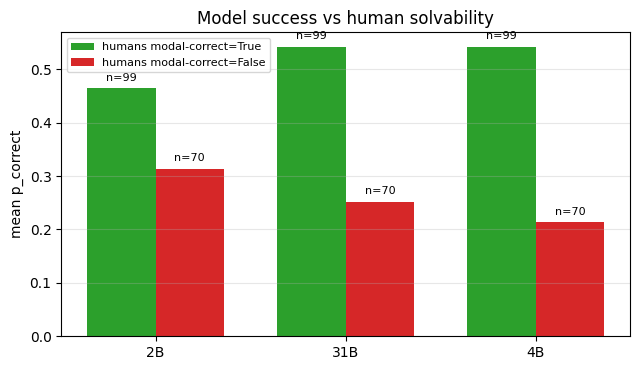

In [19]:
solv = merged[merged["n_valid_stochastic"] > 0].copy()
solv["village_modal_correct"] = solv["village_modal_correct"].astype(bool)
solv_summary = (solv.groupby(["model", "village_modal_correct"])
                .agg(n_games=("p_correct", "size"), mean_p_correct=("p_correct", "mean"))
                .round(3).reset_index())
display(solv_summary)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
x = np.arange(len(MODELS)); w = 0.36
for off, flag, color in [(-w / 2, True, "#2ca02c"), (w / 2, False, "#d62728")]:
    vals, ns = [], []
    for m in MODELS:
        s = solv_summary[(solv_summary["model"] == m) & (solv_summary["village_modal_correct"] == flag)]
        vals.append(s["mean_p_correct"].iloc[0] if len(s) else np.nan)
        ns.append(int(s["n_games"].iloc[0]) if len(s) else 0)
    bars = ax.bar(x + off, vals, w, label=f"humans modal-correct={flag}", color=color)
    for bar, n in zip(bars, ns):
        if not np.isnan(bar.get_height()):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f"n={n}",
                    ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.set_ylabel("mean p_correct"); ax.set_title("Model success vs human solvability")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


### Solvability split by `has_werewolf`

The human-failed group mixes two very different situations: werewolf-present
games the crowd misread, and no-werewolf games where the crowd wrongly voted
someone (there, `p_correct` is earned by *circle-voting*). A model with a high
circle rate can therefore lead the human-failed column without deducing
anything. Splitting by `has_werewolf` separates "found the wolf against the
crowd" from "abstained and abstaining happened to be right".


In [20]:
solv2 = merged[merged["n_valid_stochastic"] > 0].copy()
solv2["village_modal_correct"] = solv2["village_modal_correct"].astype(bool)
split = (solv2.groupby(["model", "has_werewolf", "village_modal_correct"])
         .agg(n_games=("p_correct", "size"), mean_p_correct=("p_correct", "mean"))
         .round(3).reset_index())
print("p_correct by human solvability, split by whether a Werewolf exists:")
display(split.pivot_table(index=["has_werewolf", "village_modal_correct"],
                          columns="model", values="mean_p_correct"))
print("n_games per cell:")
display(split.pivot_table(index=["has_werewolf", "village_modal_correct"],
                          columns="model", values="n_games"))

hard = split[(split["has_werewolf"] == True) & (split["village_modal_correct"] == False)]
print("Werewolf-present games the humans failed (the deduction test):")
display(hard[["model", "n_games", "mean_p_correct"]])


p_correct by human solvability, split by whether a Werewolf exists:


model                                  2B    31B     4B
has_werewolf village_modal_correct                     
False        False                  0.449  0.391  0.130
True         False                  0.248  0.184  0.255
             True                   0.465  0.542  0.542

n_games per cell:


model                                 2B   31B    4B
has_werewolf village_modal_correct                  
False        False                  23.0  23.0  23.0
True         False                  47.0  47.0  47.0
             True                   99.0  99.0  99.0

Werewolf-present games the humans failed (the deduction test):


,model,n_games,mean_p_correct
1,2B,47,0.248
4,31B,47,0.184
7,4B,47,0.255


## 7. Export for the surrogate-model step

One row per (model, game) with the behavioral quantities computed above --
usable directly as targets/features when predicting votes.


In [21]:
export = merged[["model", "game_id", "source", "session_name", "game_key", "game_class",
                 "n_valid_stochastic", "p_correct", "stoch_entropy",
                 "greedy_vote", "greedy_correct",
                 "n_village_aligned_votes", "village_top_share",
                 "village_vote_entropy", "village_modal_correct"]].copy()
export = export.merge(shares_df.drop(columns=["game_class"]), on=["model", "game_id"], how="left")
export = export.merge(start_df[["model", "game_id", "swap_game", "p_start_ww", "p_start_not_end"]],
                      on=["model", "game_id"], how="left")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
out_path = OUTPUT_DIR / "cross_model_game_features.csv"
export.to_csv(out_path, index=False)
print(f"saved {len(export)} rows -> {out_path.relative_to(REPO_ROOT)}")
display(export.head(3))


saved 507 rows -> analysis\cross_model\base\voting\prompt_v4\tables\cross_model_game_features.csv


,model,game_id,source,session_name,game_key,game_class,n_valid_stochastic,p_correct,stoch_entropy,greedy_vote,...,village_vote_entropy,village_modal_correct,werewolf,human_modal,other_human_target,unvoted_player,circle,swap_game,p_start_ww,p_start_not_end
0,31B,Ego4D / 0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0 /...,Ego4D,0a6ef9dc-a2dc-452b-a907-d6fa2ed4cae0,Game1,dissociated,3,0.333333,0.636514,Brent,...,0.636514,False,0.333333,0.0,0.0,0.666667,0.0,True,0.666667,0.666667
1,31B,Ego4D / 0c2659db-7bd4-4b37-9b08-4e247befe382 /...,Ego4D,0c2659db-7bd4-4b37-9b08-4e247befe382,Game4,dissociated,3,0.000000,-0.000000,Elliot,...,0.636514,False,0.000000,0.0,0.0,1.000000,0.0,False,0.000000,0.000000
2,31B,Ego4D / 0c2659db-7bd4-4b37-9b08-4e247befe382 /...,Ego4D,0c2659db-7bd4-4b37-9b08-4e247befe382,Game5,aligned,3,0.000000,-0.000000,Sian,...,0.562335,True,0.000000,0.0,0.0,1.000000,0.0,False,0.000000,0.000000


## Closing caveats

- Every accuracy figure travels with the random-vote baseline for the same
  games; without it the raw number is uninterpretable, because roster size and
  the number of Werewolves both move the chance level.
- Human votes are neither gold labels nor a pure social signal: villagers hold
  private night information, and their votes are downstream of the same
  dialogue the models read. "Follows the crowd" here is a description of where
  the vote lands, compatible with both conformity and shared evidence.
- Dissociated games are, by construction, games where a Werewolf fooled the
  human table -- harder games. The aligned/dissociated gap conflates removed
  social signal with raised difficulty; only transcript-manipulation probes
  can separate them.
- Every quoted number should travel with its n; between-model claims should be
  quoted only where the paired bootstrap CI excludes zero.
